In [1]:
# Core TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory

# Data Handling and Preprocessing
import numpy as np
import pandas as pd
import os
import pathlib
import cv2  # Optional: for custom image preprocessing

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# System
import warnings
warnings.filterwarnings('ignore')


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gpiosenka/sports-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sports-classification


In [3]:
import os

# List files in dataset path
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))


Streaming output truncated to the last 5000 lines.
/kaggle/input/sports-classification/train/rings/072.jpg
/kaggle/input/sports-classification/train/rings/111.jpg
/kaggle/input/sports-classification/train/rings/017.jpg
/kaggle/input/sports-classification/train/rings/145.jpg
/kaggle/input/sports-classification/train/rings/135.jpg
/kaggle/input/sports-classification/train/rings/088.jpg
/kaggle/input/sports-classification/train/rings/007.jpg
/kaggle/input/sports-classification/train/rings/057.jpg
/kaggle/input/sports-classification/train/rings/005.jpg
/kaggle/input/sports-classification/train/rings/121.jpg
/kaggle/input/sports-classification/train/rings/063.jpg
/kaggle/input/sports-classification/train/rings/070.jpg
/kaggle/input/sports-classification/train/rings/103.jpg
/kaggle/input/sports-classification/train/rings/004.jpg
/kaggle/input/sports-classification/train/rings/021.jpg
/kaggle/input/sports-classification/train/rings/126.jpg
/kaggle/input/sports-classification/train/rings/142.j

In [4]:
import shutil
destination = "/content/sports-classification"
shutil.copytree(path, destination)

print("Dataset copied to:", destination)


Dataset copied to: /content/sports-classification


In [5]:
train_dir = "/content/sports-classification/train"

# List class names
classes = os.listdir(train_dir)
print("Classes found in train/:", classes)

# Show sample files from each class
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    sample_files = os.listdir(class_path)[:5]  # Show first 5 files
    print(f"\nClass: {cls}")
    for file in sample_files:
        print(f"  {file}")


Classes found in train/: ['weightlifting', 'billiards', 'motorcycle racing', 'polo', 'judo', 'rugby', 'volleyball', 'steer wrestling', 'rollerblade racing', 'olympic wrestling', 'hang gliding', 'ultimate', 'rowing', 'tug of war', 'ampute football', 'ice climbing', 'snowmobile racing', 'bike polo', 'hydroplane racing', 'sailboat racing', 'figure skating pairs', 'wheelchair basketball', 'balance beam', 'bobsled', 'roller derby', 'figure skating men', 'luge', 'high jump', 'pole vault', 'figure skating women', 'ski jumping', 'wheelchair racing', 'arm wrestling', 'hockey', 'golf', 'air hockey', 'pommel horse', 'surfing', 'shuffleboard', 'mushing', 'baton twirling', 'lacrosse', 'sumo wrestling', 'parallel bar', 'water polo', 'archery', 'chuckwagon racing', 'track bicycle', 'giant slalom', 'axe throwing', 'bmx', 'swimming', 'basketball', 'fly fishing', 'speed skating', 'formula 1 racing', 'cricket', 'harness racing', 'bull riding', 'baseball', 'gaga', 'field hockey', 'water cycling', 'disc go

In [6]:
# Paths
train_dir = "/content/sports-classification/train"
val_dir   = "/content/sports-classification/valid"
test_dir  = "/content/sports-classification/test"

# Parameters
img_size = (224, 224)
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',  # or 'int' or 'binary' depending on your need
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Optional: Normalize pixel values
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Optimize performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)


Found 13492 files belonging to 100 classes.
Found 500 files belonging to 100 classes.
Found 500 files belonging to 100 classes.


In [7]:
import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image

# Parameters
base_dir = "/content/sports-classification/train"
img_size = (224, 224)
target_augments_per_class = 400

# Define augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

# Function to augment and save image
def save_augmented_images(img_path, output_dir, augment_count):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_tensor = tf.expand_dims(img_array, 0)

    for i in range(augment_count):
        augmented = data_augmentation(img_tensor, training=True)[0]
        augmented_img = Image.fromarray(tf.cast(augmented, tf.uint8).numpy())
        new_name = f"aug_{i}_{os.path.basename(img_path)}"
        augmented_img.save(os.path.join(output_dir, new_name))

# Loop through each class directory
for class_name in os.listdir(base_dir):
    class_dir = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_dir): continue

    existing_images = [f for f in os.listdir(class_dir) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    existing_count = len(existing_images)
    needed = target_augments_per_class

    print(f"⏳ Augmenting {class_name} | existing: {existing_count} | generating: {needed}")

    images_to_augment = existing_images * ((needed // existing_count) + 1)
    images_to_augment = images_to_augment[:needed]

    for idx, img_name in enumerate(images_to_augment):
        img_path = os.path.join(class_dir, img_name)
        save_augmented_images(img_path, class_dir, 1)  # 1 image per input


⏳ Augmenting weightlifting | existing: 134 | generating: 400
⏳ Augmenting billiards | existing: 145 | generating: 400
⏳ Augmenting motorcycle racing | existing: 132 | generating: 400
⏳ Augmenting polo | existing: 157 | generating: 400
⏳ Augmenting judo | existing: 150 | generating: 400
⏳ Augmenting rugby | existing: 166 | generating: 400
⏳ Augmenting volleyball | existing: 142 | generating: 400
⏳ Augmenting steer wrestling | existing: 122 | generating: 400
⏳ Augmenting rollerblade racing | existing: 159 | generating: 400
⏳ Augmenting olympic wrestling | existing: 167 | generating: 400
⏳ Augmenting hang gliding | existing: 121 | generating: 400
⏳ Augmenting ultimate | existing: 97 | generating: 400
⏳ Augmenting rowing | existing: 143 | generating: 400
⏳ Augmenting tug of war | existing: 128 | generating: 400
⏳ Augmenting ampute football | existing: 112 | generating: 400
⏳ Augmenting ice climbing | existing: 130 | generating: 400
⏳ Augmenting snowmobile racing | existing: 147 | generatin

In [8]:
import os

train_dir = "/content/sports-classification/train"

for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"{class_name}: {image_count} images")


air hockey: 224 images
ampute football: 224 images
archery: 264 images
arm wrestling: 198 images
axe throwing: 226 images
balance beam: 294 images
barell racing: 246 images
baseball: 348 images
basketball: 338 images
baton twirling: 216 images
bike polo: 220 images
billiards: 290 images
bmx: 280 images
bobsled: 276 images
bowling: 240 images
boxing: 232 images
bull riding: 298 images
bungee jumping: 250 images
canoe slamon: 328 images
cheerleading: 262 images
chuckwagon racing: 240 images
cricket: 258 images
croquet: 268 images
curling: 282 images
disc golf: 246 images
fencing: 270 images
field hockey: 314 images
figure skating men: 256 images
figure skating pairs: 302 images
figure skating women: 314 images
fly fishing: 268 images
football: 382 images
formula 1 racing: 380 images
frisbee: 262 images
gaga: 236 images
giant slalom: 300 images
golf: 314 images
hammer throw: 244 images
hang gliding: 242 images
harness racing: 294 images
high jump: 316 images
hockey: 344 images
horse jumpi

In [9]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load VGG16 base
vgg_base = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
vgg_base.trainable = False  # Freeze all convolutional layers initially

# Build Sequential model
model = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')  # 100 output classes
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train top layers
print("📦 Training top layers (frozen VGG16 base)...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Unfreeze some of the deeper layers in VGG16
vgg_base.trainable = True
for layer in vgg_base.layers[:15]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune
print("🔧 Fine-tuning VGG16...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Final evaluation on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Final test accuracy: {test_acc:.4f}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
📦 Training top layers (frozen VGG16 base)...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 104s 209ms/step - accuracy: 0.0685 - loss: 4.2879 - val_accuracy: 0.4320 - val_loss: 2.7818
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 75s 177ms/step - accuracy: 0.3104 - loss: 2.8189 - val_accuracy: 0.5760 - val_loss: 1.9277
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 85s 183ms/step - accuracy: 0.4271 - loss: 2.2119 - val_accuracy: 0.6140 - val_loss: 1.5711
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 177ms/step - accuracy: 0.5009 - loss: 1.8990 - val_accuracy: 0.6780 - val_loss: 1.3551
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 74s 176ms/step - accuracy: 0.5457 - loss: 1.7168 - val_accuracy: 0.7000 - val_loss: 1.2181
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 177ms/step - accuracy: 0.5771 - loss: 1.5720 - val_accuracy: 0.6960 - val_loss: 1.1295
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 177ms/step - accuracy: 0.6045 - loss: 1.4716 - val_accuracy: 0.7060 - val

In [10]:
print(2)

2


In [11]:
# Save model
model.save("vgg16_sports_classifier.h5")

# Later, load it like this
from tensorflow.keras.models import load_model
model = load_model("vgg16_sports_classifier.h5")


In [12]:
model.save("vgg16_sports_classifier.keras")  # recommended

model = tf.keras.models.load_model("vgg16_sports_classifier.keras")
model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.9130 - loss: 0.2537


[0.2979120910167694, 0.8939999938011169]

In [13]:
import shutil
import os

# Zip the directory
shutil.make_archive("/content/sports-classification", 'zip', "/content/sports-classification")

print("Directory zipped. You can download the file 'sports-classification.zip' from the files pane.")

Directory zipped. You can download the file 'sports-classification.zip' from the files pane.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


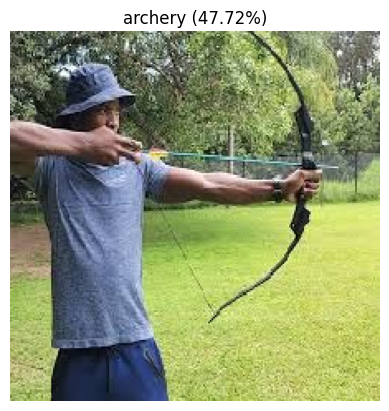

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

# === Path to image and training directory ===
img_path = "/content/sports-classification/image4.jpeg"  # <-- Change this
train_dir = "/content/sports-classification/train"
img_size = (224, 224)

# === Get class names from training folders ===
class_names = sorted(os.listdir(train_dir))

# === Load and preprocess image ===
img = image.load_img(img_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# === Predict with pretrained model ===
pred = model.predict(img_array)
predicted_index = np.argmax(pred)
confidence = np.max(pred)
predicted_class = class_names[predicted_index]

# === Show image with prediction ===
plt.imshow(img)
plt.axis('off')
plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
plt.show()
